In [14]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.5/780.5 MB 5.6 MB/s eta 0:00:0000:0100:04
  Using cached https://download-r2.pytorch.org/whl/cu121/torchvision-0.20.1%2Bcu121-cp311-cp311-linux_x86_64.whl (7.3 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchaudio-2.5.1%2Bcu121-cp311-cp311-linux_x86_64.whl (3.4 MB)
  Using cached https://download.pytorch.org/whl/cu121/nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached https://download.pytorch.org/whl/cu121/nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached https://download.pytorch.org/whl/cu121/nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached https://download.pytorch.org/whl/cu121/nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl (664.8 MB)
  Using cached https://download.pytorch.org/whl/cu121/nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux

In [30]:
import torch
print("GPU Available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0))

GPU Available: True
Device: NVIDIA A100-SXM4-40GB MIG 2g.10gb


In [2]:
import zipfile

with zipfile.ZipFile("slices.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

In [3]:
import os
os.remove("slices.zip")

In [31]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import torchvision.transforms.functional as TF
import random
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

# ── Configuration ────────────────────────────────────────────────────────────
CFG = {
    'data_dir': './dataset/slices',
    'checkpoint_dir': './checkpoints',  

    # Model
    'num_classes': 5,
    'in_channels': 1,
    'base_features': 32,

    # Training
    'img_size': 256,
    'batch_size': 8,
    'num_epochs': 10,
    'lr': 1e-4,
    'weight_decay': 1e-5,
    'val_split': 0.15,
    'seed': 42,

    # Loss
    'dice_weight': 0.6,
    'bce_weight': 0.4,

    # Misc
    'num_workers': 4,
    'pin_memory': True,
    'use_amp': True,
    'organ_names': ['Liver', 'Spleen', 'Left Kidney', 'Right Kidney', 'Pancreas'],
}

# ── Reproducibility ───────────────────────────────────────────────────────────
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CFG['seed'])

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'VRAM   : {total:.1f} GB')

os.makedirs(CFG['checkpoint_dir'], exist_ok=True)

Device : cuda
GPU    : NVIDIA A100-SXM4-40GB MIG 2g.10gb
VRAM   : 10.5 GB


In [32]:
class CTSegDataset(Dataset):
    """
    Expects:
      image_dir/  — *.npy files, each shape (H, W), HU values
      mask_dir/   — *.npy files, each shape (5, H, W), binary {0,1}
    File stems must match between image_dir and mask_dir.
    """
    def __init__(self, image_paths, mask_paths, img_size=256, augment=False):
        self.image_paths = image_paths
        self.mask_paths  = mask_paths
        self.img_size    = img_size
        self.augment     = augment

    def __len__(self):
        return len(self.image_paths)

    def _normalize_ct(self, img: np.ndarray) -> np.ndarray:
        """Clip to soft-tissue window then min-max normalize to [0,1]."""
        img = np.clip(img, -175, 250)   # HU window: abdomen soft tissue
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        return img.astype(np.float32)

    def _augment(self, image: torch.Tensor, mask: torch.Tensor):
        """Joint augmentation — same random transform applied to image AND mask."""
        # Random horizontal flip
        if random.random() > 0.5:
            image = TF.hflip(image)
            mask  = TF.hflip(mask)

        # Random vertical flip
        if random.random() > 0.5:
            image = TF.vflip(image)
            mask  = TF.vflip(mask)

        # Random rotation ±15°
        if random.random() > 0.5:
            angle = random.uniform(-15, 15)
            image = TF.rotate(image, angle)
            mask  = TF.rotate(mask,  angle)

        # Random brightness / contrast (image only)
        if random.random() > 0.5:
            image = TF.adjust_brightness(image, random.uniform(0.8, 1.2))
            image = TF.adjust_contrast(image,   random.uniform(0.8, 1.2))

        return image, mask

    def __getitem__(self, idx):
        image = np.load(self.image_paths[idx])  # (H, W)
        mask  = np.load(self.mask_paths[idx])   # (5, H, W)

        image = self._normalize_ct(image)
        mask  = (mask > 0.5).astype(np.float32)

        # → tensors
        image = torch.from_numpy(image).unsqueeze(0)  # (1, H, W)
        mask  = torch.from_numpy(mask)                # (5, H, W)

        # Resize
        s = self.img_size
        image = F.interpolate(image.unsqueeze(0), (s, s), mode='bilinear',  align_corners=False).squeeze(0)
        mask  = F.interpolate(mask.unsqueeze(0),  (s, s), mode='nearest').squeeze(0)

        if self.augment:
            image, mask = self._augment(image, mask)

        return image, mask


def build_loaders(cfg):
    folder = Path(cfg['data_dir'])

    ct_files = sorted(folder.glob('*_ct.npy'))
    mask_files = sorted(folder.glob('*_mask.npy'))

    assert len(ct_files) == len(mask_files) > 0, "Dataset mismatch!"

    n = len(ct_files)
    n_val = int(n * cfg['val_split'])

    indices = list(range(n))
    random.shuffle(indices)

    val_idx = indices[:n_val]
    trn_idx = indices[n_val:]

    trn_imgs = [ct_files[i] for i in trn_idx]
    trn_masks = [mask_files[i] for i in trn_idx]

    val_imgs = [ct_files[i] for i in val_idx]
    val_masks = [mask_files[i] for i in val_idx]

    trn_ds = CTSegDataset(trn_imgs, trn_masks, cfg['img_size'], augment=True)
    val_ds = CTSegDataset(val_imgs, val_masks, cfg['img_size'], augment=False)

    trn_loader = DataLoader(trn_ds, batch_size=cfg['batch_size'], shuffle=True,
                           num_workers=cfg['num_workers'], pin_memory=cfg['pin_memory'],
                           drop_last=True)

    val_loader = DataLoader(val_ds, batch_size=cfg['batch_size'], shuffle=False,
                           num_workers=cfg['num_workers'], pin_memory=cfg['pin_memory'])

    print(f"Train: {len(trn_ds)} | Val: {len(val_ds)}")

    return trn_loader, val_loader


# ── Sanity check (runs without actual data files) ─────────────────────────────
# trn_loader, val_loader = build_loaders(CFG)
print('Dataset class ready — call build_loaders(CFG) once your data paths are set.')

Dataset class ready — call build_loaders(CFG) once your data paths are set.


In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# Building Blocks
# ─────────────────────────────────────────────────────────────────────────────

class DoubleConv(nn.Module):
    """(Conv → BN → ReLU) × 2  — the core U-Net block."""
    def __init__(self, in_ch, out_ch, mid_ch=None):
        super().__init__()
        mid_ch = mid_ch or out_ch
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  mid_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(mid_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class AttentionGate(nn.Module):
    """
    Soft attention gate from Oktay et al. (2018).
    Learns *where* to focus on the skip-connection features.
    g  = gating signal from decoder (coarser)
    x  = skip connection from encoder (finer)
    """
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, 1, bias=True),
            nn.BatchNorm2d(F_int),
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, 1, bias=True),
            nn.BatchNorm2d(F_int),
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, 1, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid(),
        )

    def forward(self, g, x):
        g1  = self.W_g(g)
        x1  = self.W_x(x)
        # upsample g to match x spatial size
        g1  = F.interpolate(g1, size=x1.shape[2:], mode='bilinear', align_corners=False)
        psi = self.psi(F.relu(g1 + x1, inplace=True))
        return x * psi   # attended skip features


# ─────────────────────────────────────────────────────────────────────────────
# Attention U-Net
# ─────────────────────────────────────────────────────────────────────────────

class AttentionUNet(nn.Module):
    def __init__(self, in_channels=1, num_classes=5, base_features=32):
        super().__init__()
        f = base_features   # 32, 64, 128, 256, 512

        # ── Encoder ──────────────────────────────────────────────────────────
        self.enc1 = DoubleConv(in_channels, f)
        self.enc2 = DoubleConv(f,     f*2)
        self.enc3 = DoubleConv(f*2,   f*4)
        self.enc4 = DoubleConv(f*4,   f*8)
        self.pool = nn.MaxPool2d(2)

        # ── Bottleneck ───────────────────────────────────────────────────────
        self.bottleneck = DoubleConv(f*8, f*16)

        # ── Decoder (with attention gates) ───────────────────────────────────
        self.att4 = AttentionGate(F_g=f*16, F_l=f*8,  F_int=f*8)
        self.up4  = nn.ConvTranspose2d(f*16, f*8, 2, stride=2)
        self.dec4 = DoubleConv(f*16, f*8)

        self.att3 = AttentionGate(F_g=f*8,  F_l=f*4,  F_int=f*4)
        self.up3  = nn.ConvTranspose2d(f*8,  f*4, 2, stride=2)
        self.dec3 = DoubleConv(f*8,  f*4)

        self.att2 = AttentionGate(F_g=f*4,  F_l=f*2,  F_int=f*2)
        self.up2  = nn.ConvTranspose2d(f*4,  f*2, 2, stride=2)
        self.dec2 = DoubleConv(f*4,  f*2)

        self.att1 = AttentionGate(F_g=f*2,  F_l=f,    F_int=f)
        self.up1  = nn.ConvTranspose2d(f*2,  f,   2, stride=2)
        self.dec1 = DoubleConv(f*2,  f)

        # ── Output ───────────────────────────────────────────────────────────
        self.out_conv = nn.Conv2d(f, num_classes, 1)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        # Encoder
        s1 = self.enc1(x)              # (B, f,   H,   W)
        s2 = self.enc2(self.pool(s1))  # (B, f*2, H/2, W/2)
        s3 = self.enc3(self.pool(s2))  # (B, f*4, H/4, W/4)
        s4 = self.enc4(self.pool(s3))  # (B, f*8, H/8, W/8)

        # Bottleneck
        b  = self.bottleneck(self.pool(s4))  # (B, f*16, H/16, W/16)

        # Decoder with attention
        d4 = self.dec4(torch.cat([self.att4(b,  s4), self.up4(b)],  dim=1))
        d3 = self.dec3(torch.cat([self.att3(d4, s3), self.up3(d4)], dim=1))
        d2 = self.dec2(torch.cat([self.att2(d3, s2), self.up2(d3)], dim=1))
        d1 = self.dec1(torch.cat([self.att1(d2, s1), self.up1(d2)], dim=1))

        return self.out_conv(d1)  # (B, num_classes, H, W) — raw logits


# ── Quick parameter count ─────────────────────────────────────────────────────
model = AttentionUNet(
    in_channels   = CFG['in_channels'],
    num_classes   = CFG['num_classes'],
    base_features = CFG['base_features'],
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters : {total_params:,}   ({total_params/1e6:.1f} M)')

# Estimate VRAM for one batch (fp16)
dummy = torch.randn(CFG['batch_size'], 1, CFG['img_size'], CFG['img_size']).to(DEVICE)
with torch.no_grad(), autocast():
    out = model(dummy)
print(f'Output shape     : {tuple(out.shape)}')
print(f'Peak VRAM        : {torch.cuda.max_memory_allocated()/1e9:.2f} GB')
del dummy, out
torch.cuda.empty_cache()

Model parameters : 8,027,089   (8.0 M)
Output shape     : (8, 5, 256, 256)
Peak VRAM        : 1.29 GB


In [34]:
class DiceLoss(nn.Module):
    """
    Soft Dice loss — works per-channel then averages.
    Handles class imbalance natively (organs are tiny vs background).
    """
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)        # (B, C, H, W)
        B, C = probs.shape[:2]
        probs   = probs.view(B, C, -1)       # (B, C, N)
        targets = targets.view(B, C, -1)

        intersection = (probs * targets).sum(dim=2)            # (B, C)
        dice = (2 * intersection + self.smooth) / \
               (probs.sum(dim=2) + targets.sum(dim=2) + self.smooth)
        return 1.0 - dice.mean()


class CombinedLoss(nn.Module):
    """
    Combined Dice + Binary Cross-Entropy loss.
    - Dice: handles class imbalance, directly optimizes the Dice metric
    - BCE:  provides stable gradients at the start of training
    """
    def __init__(self, dice_weight=0.6, bce_weight=0.4):
        super().__init__()
        self.dice     = DiceLoss()
        self.bce      = nn.BCEWithLogitsLoss()
        self.dw       = dice_weight
        self.bw       = bce_weight

    def forward(self, logits, targets):
        return self.dw * self.dice(logits, targets) + \
               self.bw * self.bce(logits, targets)


# ── Dice metric (for evaluation — hard predictions) ───────────────────────────
@torch.no_grad()
def dice_score(logits, targets, threshold=0.5, eps=1e-8):
    """
    Returns per-class and mean Dice scores.
    logits  : (B, C, H, W)  — raw model output
    targets : (B, C, H, W)  — binary ground truth
    """
    preds   = (torch.sigmoid(logits) > threshold).float()
    B, C    = preds.shape[:2]
    preds   = preds.view(B, C, -1)
    targets = targets.view(B, C, -1)

    intersection = (preds * targets).sum(dim=2)              # (B, C)
    dice = (2 * intersection + eps) / \
           (preds.sum(dim=2) + targets.sum(dim=2) + eps)
    per_class = dice.mean(dim=0)   # (C,)
    mean_dice = per_class.mean()   # scalar
    return per_class, mean_dice


criterion = CombinedLoss(CFG['dice_weight'], CFG['bce_weight'])
print('Loss function ready.')

Loss function ready.


In [35]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = CFG['lr'],
    weight_decay = CFG['weight_decay'],
)

# Cosine annealing — smoothly decays LR over training
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max  = CFG['num_epochs'],
    eta_min= 1e-6,
)

# Mixed-precision scaler (fp16 — halves VRAM, 2-3× faster on A100)
scaler = GradScaler(enabled=CFG['use_amp'])

print('Optimizer : AdamW')
print('Scheduler : CosineAnnealingLR')
print(f'AMP       : {CFG["use_amp"]}')

Optimizer : AdamW
Scheduler : CosineAnnealingLR
AMP       : True


In [36]:
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    total_loss = 0.0
    per_class_dice = torch.zeros(CFG['num_classes'])

    pbar = tqdm(loader, desc='  Train', leave=False)
    for images, masks in pbar:
        images = images.to(device, non_blocking=True)
        masks  = masks.to(device,  non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast(enabled=CFG['use_amp']):
            logits = model(images)
            loss   = criterion(logits, masks)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        pc, md = dice_score(logits.detach(), masks)
        per_class_dice += pc.cpu()

        pbar.set_postfix(loss=f'{loss.item():.4f}', dice=f'{md.item():.4f}')

    n = len(loader)
    return total_loss / n, per_class_dice / n


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    per_class_dice = torch.zeros(CFG['num_classes'])

    pbar = tqdm(loader, desc='  Val  ', leave=False)
    for images, masks in pbar:
        images = images.to(device, non_blocking=True)
        masks  = masks.to(device,  non_blocking=True)

        with autocast(enabled=CFG['use_amp']):
            logits = model(images)
            loss   = criterion(logits, masks)

        total_loss += loss.item()
        pc, _ = dice_score(logits, masks)
        per_class_dice += pc.cpu()

    n = len(loader)
    return total_loss / n, per_class_dice / n


print('Train / validate functions ready.')

Train / validate functions ready.


In [37]:
# ── Main Training Loop ────────────────────────────────────────────────────────

# ❗ Build loaders (point to your actual data)
trn_loader, val_loader = build_loaders(CFG)

history = {'trn_loss': [], 'val_loss': [], 'trn_dice': [], 'val_dice': []}
best_dice = 0.0
best_ckpt = Path(CFG['checkpoint_dir']) / 'best_model.pth'

print(f'Starting training for {CFG["num_epochs"]} epochs\n')

for epoch in range(1, CFG['num_epochs'] + 1):
    trn_loss, trn_pc = train_one_epoch(model, trn_loader, optimizer, criterion, scaler, DEVICE)
    val_loss, val_pc = validate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    trn_dice = trn_pc.mean().item()
    val_dice = val_pc.mean().item()

    history['trn_loss'].append(trn_loss)
    history['val_loss'].append(val_loss)
    history['trn_dice'].append(trn_dice)
    history['val_dice'].append(val_dice)

    # Save best checkpoint
    if val_dice > best_dice:
        best_dice = val_dice
        torch.save({
            'epoch':      epoch,
            'state_dict': model.state_dict(),
            'optimizer':  optimizer.state_dict(),
            'val_dice':   val_dice,
            'cfg':        CFG,
        }, best_ckpt)
        flag = '  ← best'
    else:
        flag = ''

    lr_now = optimizer.param_groups[0]['lr']
    per = '  '.join([f'{CFG["organ_names"][i][0]}.{val_pc[i]:.3f}' for i in range(CFG['num_classes'])])
    print(f'Ep {epoch:03d}/{CFG["num_epochs"]} │ '
          f'trn {trn_loss:.4f}/{trn_dice:.4f} │ '
          f'val {val_loss:.4f}/{val_dice:.4f} │ '
          f'lr {lr_now:.1e} │ [{per}]{flag}')

Train: 9208 | Val: 1624
Starting training for 10 epochs



  Train:   0%|          | 0/1151 [00:00<?, ?it/s]

  Val  :   0%|          | 0/203 [00:00<?, ?it/s]

Ep 001/10 │ trn 0.6334/0.2303 │ val 0.5536/0.4711 │ lr 9.8e-05 │ [L.0.684  S.0.243  L.0.552  R.0.320  P.0.557]  ← best


  Train:   0%|          | 0/1151 [00:00<?, ?it/s]

...

  Val  :   0%|          | 0/203 [00:00<?, ?it/s]

Ep 009/10 │ trn 0.1154/0.8808 │ val 0.1016/0.8927 │ lr 3.4e-06 │ [L.0.898  S.0.921  L.0.817  R.0.922  P.0.906]  ← best


  Train:   0%|          | 0/1151 [00:00<?, ?it/s]

  Val  :   0%|          | 0/203 [00:00<?, ?it/s]

Ep 010/10 │ trn 0.1055/0.8862 │ val 0.0986/0.8936 │ lr 1.0e-06 │ [L.0.895  S.0.921  L.0.821  R.0.920  P.0.912]  ← best


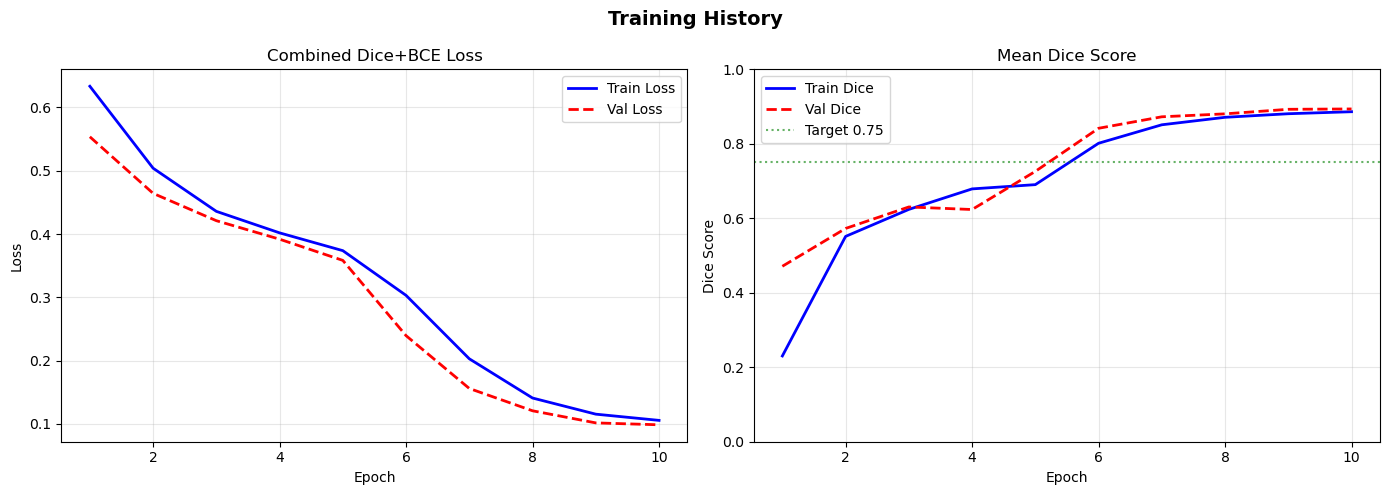

Best Validation Dice : 0.8936


In [38]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

epochs = range(1, len(history['trn_loss']) + 1)

ax1.plot(epochs, history['trn_loss'], 'b-',  label='Train Loss', linewidth=2)
ax1.plot(epochs, history['val_loss'], 'r--', label='Val Loss',   linewidth=2)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('Combined Dice+BCE Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs, history['trn_dice'], 'b-',  label='Train Dice', linewidth=2)
ax2.plot(epochs, history['val_dice'], 'r--', label='Val Dice',   linewidth=2)
ax2.axhline(0.75, color='green', linestyle=':', alpha=0.6, label='Target 0.75')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Dice Score'); ax2.set_title('Mean Dice Score')
ax2.legend(); ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Best Validation Dice : {best_dice:.4f}')

In [39]:
# ── Load best checkpoint ──────────────────────────────────────────────────────
ckpt = torch.load(best_ckpt, map_location=DEVICE)
model.load_state_dict(ckpt['state_dict'])
print(f'Loaded checkpoint from epoch {ckpt["epoch"]} (val_dice={ckpt["val_dice"]:.4f})')

# ── Full validation evaluation ────────────────────────────────────────────────
model.eval()
all_dice = torch.zeros(CFG['num_classes'])
n_batches = 0

with torch.no_grad():
    for images, masks in tqdm(val_loader, desc='Evaluating'):
        images = images.to(DEVICE)
        masks  = masks.to(DEVICE)
        with autocast(enabled=CFG['use_amp']):
            logits = model(images)
        pc, _ = dice_score(logits, masks)
        all_dice += pc.cpu()
        n_batches += 1

all_dice /= n_batches
print('\n── Per-Organ Dice Scores ──────────────────────')
for i, name in enumerate(CFG['organ_names']):
    bar = '█' * int(all_dice[i] * 30)
    print(f'  {name:<15} {all_dice[i]:.4f}  {bar}')
print(f'  {"Mean":<15} {all_dice.mean():.4f}')

Loaded checkpoint from epoch 10 (val_dice=0.8936)


Evaluating:   0%|          | 0/203 [00:00<?, ?it/s]


── Per-Organ Dice Scores ──────────────────────
  Liver           0.8945  ██████████████████████████
  Spleen          0.9213  ███████████████████████████
  Left Kidney     0.8207  ████████████████████████
  Right Kidney    0.9197  ███████████████████████████
  Pancreas        0.9118  ███████████████████████████
  Mean            0.8936


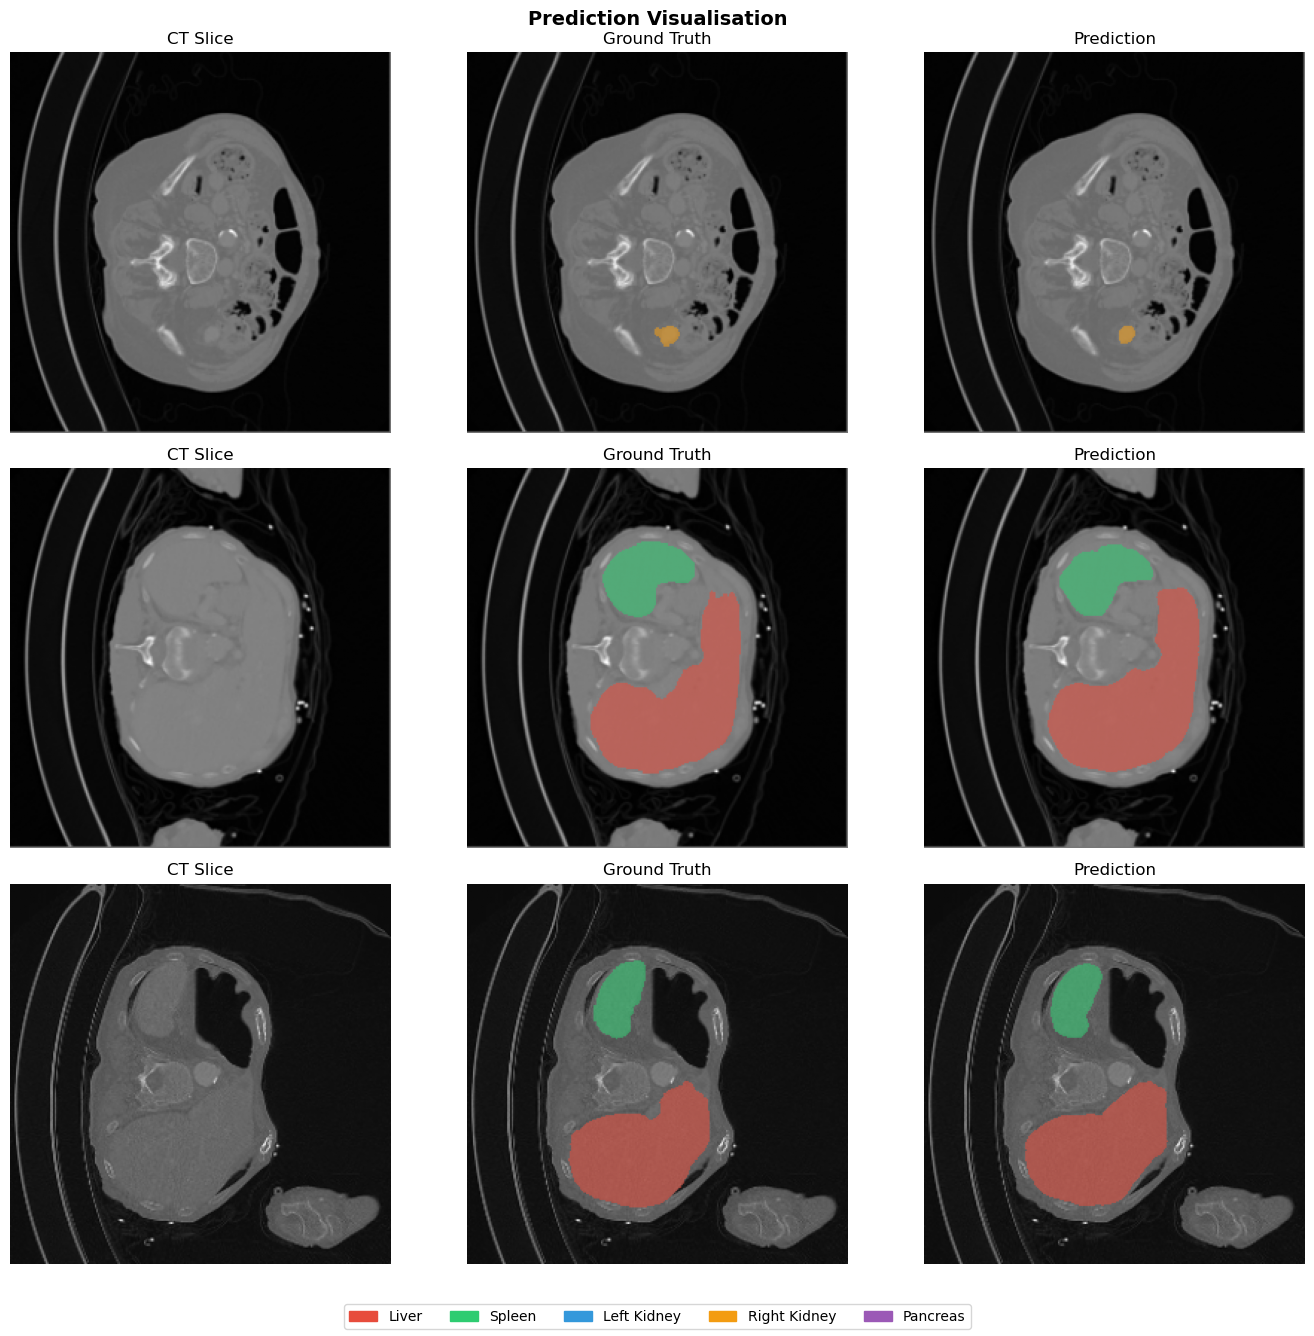

In [40]:
# ── Visual Prediction Check ───────────────────────────────────────────────────
COLORS = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12', '#9b59b6']

def visualize_predictions(model, loader, device, num_samples=3):
    model.eval()
    images, masks = next(iter(loader))
    images = images.to(device)

    with torch.no_grad(), autocast(enabled=CFG['use_amp']):
        logits = model(images)
    preds = (torch.sigmoid(logits) > 0.5).cpu().float()

    num_samples = min(num_samples, images.shape[0])
    fig, axes = plt.subplots(num_samples, 3, figsize=(14, 4.5 * num_samples))
    if num_samples == 1: axes = axes[np.newaxis, :]

    for i in range(num_samples):
        img_np = images[i, 0].cpu().numpy()

        # CT image
        axes[i, 0].imshow(img_np, cmap='gray')
        axes[i, 0].set_title('CT Slice'); axes[i, 0].axis('off')

        # Ground truth overlay
        axes[i, 1].imshow(img_np, cmap='gray')
        for c in range(CFG['num_classes']):
            mask_c = masks[i, c].numpy()
            rgba = np.zeros((*mask_c.shape, 4))
            r, g, b = tuple(int(COLORS[c][j:j+2], 16)/255 for j in (1,3,5))
            rgba[..., :3] = [r, g, b]
            rgba[..., 3]  = mask_c * 0.55
            axes[i, 1].imshow(rgba)
        axes[i, 1].set_title('Ground Truth'); axes[i, 1].axis('off')

        # Prediction overlay
        axes[i, 2].imshow(img_np, cmap='gray')
        for c in range(CFG['num_classes']):
            pred_c = preds[i, c].numpy()
            rgba = np.zeros((*pred_c.shape, 4))
            r, g, b = tuple(int(COLORS[c][j:j+2], 16)/255 for j in (1,3,5))
            rgba[..., :3] = [r, g, b]
            rgba[..., 3]  = pred_c * 0.55
            axes[i, 2].imshow(rgba)
        axes[i, 2].set_title('Prediction'); axes[i, 2].axis('off')

    patches = [mpatches.Patch(color=COLORS[c], label=CFG['organ_names'][c])
               for c in range(CFG['num_classes'])]
    fig.legend(handles=patches, loc='lower center', ncol=5, fontsize=10, framealpha=0.8)
    plt.suptitle('Prediction Visualisation', fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.savefig('predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_predictions(model, val_loader, DEVICE)

In [41]:
torch.save(model.state_dict(), "baseline_model.pth")
print("Baseline model saved")

Baseline model saved


In [44]:
model = AttentionUNet(
    in_channels=CFG['in_channels'],
    num_classes=CFG['num_classes']
).to(DEVICE)

model.load_state_dict(torch.load("baseline_model.pth"))
print("Model loaded")

Model loaded


In [49]:
trn_loader, val_loader = build_loaders(CFG)

train_dataset = trn_loader.dataset

print("Train dataset:", len(train_dataset))

Train: 9208 | Val: 1624
Train dataset: 9208


In [47]:
def dirichlet_partition(dataset, num_clients=3, alpha=0.5, seed=42):
    import numpy as np
    from collections import defaultdict

    rng = np.random.default_rng(seed)

    class_indices = defaultdict(list)

    # ✅ FIXED LOOP
    for idx in range(len(dataset)):
        _, mask = dataset[idx]

        mask_np = mask.numpy() if hasattr(mask, 'numpy') else np.array(mask)

        # Convert one-hot → class index
        if mask_np.ndim == 3:
            mask_np = np.argmax(mask_np, axis=0)

        dominant = int(np.bincount(mask_np.flatten()).argmax())

        class_indices[dominant].append(idx)   # ✅ IMPORTANT

    client_indices = [[] for _ in range(num_clients)]  # ✅ IMPORTANT

    for cls, indices in class_indices.items():
        rng.shuffle(indices)

        proportions = rng.dirichlet(alpha=np.repeat(alpha, num_clients))
        proportions = (np.cumsum(proportions) * len(indices)).astype(int)

        splits = np.split(indices, proportions[:-1])

        for c, split in enumerate(splits):
            client_indices[c].extend(split.tolist())

    return client_indices

def make_client_loaders(dataset, num_clients=3, batch_size=8, alpha=0.5):
    """Returns list of DataLoaders, one per client."""
    partitions = dirichlet_partition(dataset, num_clients=num_clients, alpha=alpha)
    loaders = []
    for i, indices in enumerate(partitions):
        subset = Subset(dataset, indices)
        loader = DataLoader(subset, batch_size=batch_size, shuffle=True,
                            num_workers=2, pin_memory=True)
        print(f"  Client {i+1}: {len(indices)} samples")
        loaders.append(loader)
    return loaders

In [50]:
client_loaders = make_client_loaders(train_dataset, num_clients=3, alpha=1.0)

print("Clients ready:", len(client_loaders))

  Client 1: 1389 samples
  Client 2: 4599 samples
  Client 3: 3220 samples
Clients ready: 3


In [52]:
# federated_client.py
import copy
import torch
from torch.cuda.amp import autocast, GradScaler

def train_one_client(model, dataloader, device, num_epochs=1, lr=1e-4):
    """
    Trains a local model copy for num_epochs.
    Returns updated state_dict and average training loss.
    """
    local_model = copy.deepcopy(model).to(device)
    optimizer = torch.optim.AdamW(local_model.parameters(), lr=lr, weight_decay=1e-5)
    scaler = GradScaler(enabled=(device.type == "cuda"))
    criterion = dice_bce_loss  # your existing loss function

    local_model.train()
    total_loss = 0.0
    steps = 0

    for epoch in range(num_epochs):
        for images, masks in dataloader:
            images = images.to(device, non_blocking=True)
            masks  = masks.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with autocast(enabled=(device.type == "cuda")):
                preds = local_model(images)
                loss  = criterion(preds, masks)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()
            steps += 1

    avg_loss = total_loss / max(steps, 1)
    return local_model.state_dict(), avg_loss

In [55]:
# federated_aggregation.py
import torch
import copy

def fedavg(global_model, client_state_dicts, client_sizes):
    """
    Federated averaging (McMahan et al., 2017).
    client_state_dicts : list of OrderedDicts from each client
    client_sizes       : list of ints (number of samples per client)
    Returns new aggregated state_dict.
    """
    total = sum(client_sizes)
    weights = [n / total for n in client_sizes]

    agg_state = copy.deepcopy(client_state_dicts[0])

    for key in agg_state:
        agg_state[key] = sum(
            w * sd[key].to(agg_state[key].device)
            for w, sd in zip(weights, client_state_dicts)
        )

    global_model.load_state_dict(agg_state)
    return global_model

In [58]:
# federated_train.py
import torch
import copy
from collections import defaultdict

def federated_train(
    global_model,
    client_loaders,
    val_loader,
    device,
    num_rounds=5,
    local_epochs=1,
    lr=1e-4,
):
    """
    Full federated training loop.
    Returns history dict with per-round metrics.
    """
    history = defaultdict(list)
    global_model = global_model.to(device)

    for rnd in range(1, num_rounds + 1):
        print(f"\n{'='*50}")
        print(f"  Round {rnd}/{num_rounds}")
        print(f"{'='*50}")

        client_state_dicts = []
        client_sizes       = []
        round_losses       = []

        # ── 1. Distribute global weights & train each client ──────────────
        for i, loader in enumerate(client_loaders):
            state_dict, client_loss = train_one_client(
                model=global_model,
                dataloader=loader,
                device=device,
                num_epochs=local_epochs,
                lr=lr,
            )
            client_state_dicts.append(state_dict)
            client_sizes.append(len(loader.dataset))
            round_losses.append(client_loss)
            print(f"  Client {i+1}: loss={client_loss:.4f}  "
                  f"samples={len(loader.dataset)}")

        # ── 2. Aggregate ──────────────────────────────────────────────────
        global_model = fedavg(global_model, client_state_dicts, client_sizes)

        # ── 3. Evaluate global model ──────────────────────────────────────
        val_loss, per_class = validate(global_model, val_loader, criterion, device)
        val_dice = per_class.mean().item()

        avg_loss = sum(round_losses) / len(round_losses)
        history['round'].append(rnd)
        history['avg_client_loss'].append(avg_loss)
        history['val_dice'].append(val_dice)
        history['per_class_dice'].append(per_class)

        print(f"\n  [Round {rnd}] Avg client loss : {avg_loss:.4f}")
        print(f"  [Round {rnd}] Val Dice (mean) : {val_dice:.4f}")
        class_names = ['Liver', 'Spleen', 'Left Kidney', 'Right Kidney', 'Pancreas']
        for cls, d in zip(class_names, per_class):
            print(f"    {cls:<12}: {d:.4f}")

    return global_model, history

In [60]:
# federated_eval.py
import torch
import numpy as np

@torch.no_grad()
def evaluate_model(model, val_loader, device, num_classes=5):
    """
    Computes mean Dice and per-class Dice on the validation set.
    Assumes masks are integer class maps (0..num_classes-1).
    """
    model.eval()
    model.to(device)

    dice_per_class = torch.zeros(num_classes, device=device)
    count = 0

    for images, masks in val_loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        # Convert one-hot → class index
        if masks.ndim == 4:
            masks = masks.argmax(dim=1)

        preds = model(images)                      # (B, C, H, W)
        preds = torch.softmax(preds, dim=1)
        pred_classes = preds.argmax(dim=1)         # (B, H, W)

        for cls in range(num_classes):
            pred_c = (pred_classes == cls).float()
            true_c = (masks == cls).float()
            intersection = (pred_c * true_c).sum()
            denom = pred_c.sum() + true_c.sum() + 1e-6
            dice_per_class[cls] += 2.0 * intersection / denom

        count += 1

    dice_per_class /= max(count, 1)
    mean_dice = dice_per_class[1:].mean()          # skip background
    return mean_dice.item(), dice_per_class.cpu().tolist()

In [65]:
import torch
import torch.nn.functional as F

def dice_bce_loss(preds, targets, smooth=1e-6):
    preds = torch.sigmoid(preds)

    intersection = (preds * targets).sum(dim=(2,3))
    dice = (2. * intersection + smooth) / (preds.sum(dim=(2,3)) + targets.sum(dim=(2,3)) + smooth)
    dice_loss = 1 - dice.mean()

    bce = F.binary_cross_entropy_with_logits(preds, targets)

    return dice_loss + bce

Device: cuda
Baseline model loaded.
Train: 9208 | Val: 1624

Partitioning dataset into 3 non-IID clients (α=1.0)...
  Client 1: 1389 samples
  Client 2: 4599 samples
  Client 3: 3220 samples


  Val  :   0%|          | 0/203 [00:00<?, ?it/s]


Baseline (centralized) Val Dice: 0.8967

  Round 1/5
  Client 1: loss=1.3094  samples=1389
  Client 2: loss=1.3043  samples=4599
  Client 3: loss=1.2996  samples=3220


  Val  :   0%|          | 0/203 [00:00<?, ?it/s]


  [Round 1] Avg client loss : 1.3044
  [Round 1] Val Dice (mean) : 0.7628
    Liver       : 0.8405
    Spleen      : 0.6985
    Left Kidney : 0.6569
    Right Kidney: 0.8425
    Pancreas    : 0.7759

  Round 2/5
  Client 1: loss=1.3058  samples=1389
  Client 2: loss=1.2993  samples=4599
  Client 3: loss=1.2969  samples=3220


...


  [Round 3] Avg client loss : 1.2968
  [Round 3] Val Dice (mean) : 0.7569
    Liver       : 0.8574
    Spleen      : 0.7049
    Left Kidney : 0.6161
    Right Kidney: 0.8307
    Pancreas    : 0.7757

  Round 4/5
  Client 1: loss=1.2952  samples=1389
  Client 2: loss=1.2929  samples=4599
  Client 3: loss=1.2881  samples=3220


  Val  :   0%|          | 0/203 [00:00<?, ?it/s]


  [Round 4] Avg client loss : 1.2921
  [Round 4] Val Dice (mean) : 0.6960
    Liver       : 0.8111
    Spleen      : 0.6575
    Left Kidney : 0.6447
    Right Kidney: 0.8220
    Pancreas    : 0.5448

  Round 5/5
  Client 1: loss=1.2962  samples=1389
  Client 2: loss=1.2898  samples=4599
  Client 3: loss=1.2868  samples=3220


  Val  :   0%|          | 0/203 [00:00<?, ?it/s]


  [Round 5] Avg client loss : 1.2910
  [Round 5] Val Dice (mean) : 0.7288
    Liver       : 0.8432
    Spleen      : 0.7614
    Left Kidney : 0.5754
    Right Kidney: 0.8388
    Pancreas    : 0.6250
Federated model saved.


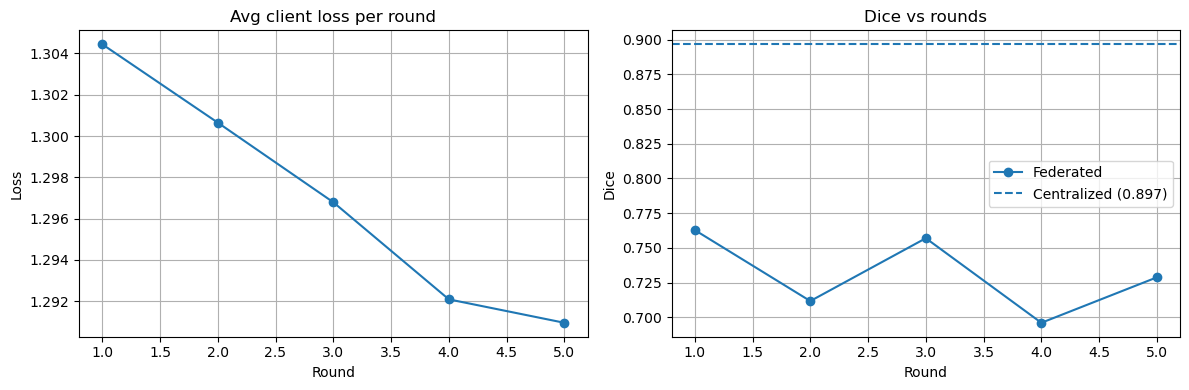

  Val  :   0%|          | 0/203 [00:00<?, ?it/s]


── Final comparison ───────────────────────────────
Class               Centralized    Federated
---------------------------------------------
Liver              0.9100 0.8432
Spleen             0.9247 0.7614
Left Kidney        0.8253 0.5754
Right Kidney       0.9168 0.8388
Pancreas           0.9066 0.6250
---------------------------------------------
Mean Dice          0.8967 0.7288


In [66]:
# ── Cell 1: Imports and config ────────────────────────────────────────────
import torch
import matplotlib.pyplot as plt

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_CLIENTS = 3
NUM_ROUNDS  = 5
BATCH_SIZE  = 8
ALPHA       = 1.0

print(f"Device: {DEVICE}")

# ── Cell 2: Load baseline model ───────────────────────────────────────────
global_model = AttentionUNet(in_channels=1, num_classes=5)
global_model.load_state_dict(torch.load('baseline_model.pth', map_location=DEVICE))
global_model = global_model.to(DEVICE)

print("Baseline model loaded.")

# ── Cell 3: Load datasets ─────────────────────────────────────────────────
trn_loader, val_loader = build_loaders(CFG)
train_dataset = trn_loader.dataset

# Non-IID partition
print(f"\nPartitioning dataset into {NUM_CLIENTS} non-IID clients (α={ALPHA})...")
client_loaders = make_client_loaders(
    train_dataset,
    num_clients=NUM_CLIENTS,
    batch_size=BATCH_SIZE,
    alpha=ALPHA
)

# ── Cell 4: Baseline evaluation (CORRECT) ─────────────────────────────────
criterion = dice_bce_loss

val_loss, per_class = validate(global_model, val_loader, criterion, DEVICE)
baseline_dice = per_class.mean().item()
baseline_per_class = per_class

print(f"\nBaseline (centralized) Val Dice: {baseline_dice:.4f}")

# ── Cell 5: Federated training ────────────────────────────────────────────
fed_model, history = federated_train(
    global_model   = global_model,
    client_loaders = client_loaders,
    val_loader     = val_loader,
    device         = DEVICE,
    num_rounds     = NUM_ROUNDS,
    local_epochs   = 1,
    lr             = 1e-4,
)

# ── Cell 6: Save federated model ──────────────────────────────────────────
torch.save(fed_model.state_dict(), 'federated_model.pth')
print("Federated model saved.")

# ── Cell 7: Plot learning curves ──────────────────────────────────────────
rounds = history['round']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(rounds, history['avg_client_loss'], marker='o')
axes[0].set_title('Avg client loss per round')
axes[0].set_xlabel('Round')
axes[0].set_ylabel('Loss')
axes[0].grid()

axes[1].plot(rounds, history['val_dice'], marker='o', label='Federated')
axes[1].axhline(baseline_dice, linestyle='--', label=f'Centralized ({baseline_dice:.3f})')
axes[1].set_title('Dice vs rounds')
axes[1].set_xlabel('Round')
axes[1].set_ylabel('Dice')
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.savefig('federated_vs_baseline.png')
plt.show()

# ── Cell 8: Final comparison ──────────────────────────────────────────────
val_loss, per_class = validate(fed_model, val_loader, criterion, DEVICE)
final_dice = per_class.mean().item()
final_per_class = per_class

class_names = ['Liver', 'Spleen', 'Left Kidney', 'Right Kidney', 'Pancreas']

print("\n── Final comparison ───────────────────────────────")
print(f"{'Class':<18} {'Centralized':>12} {'Federated':>12}")
print("-" * 45)

for cls, b, f in zip(class_names, baseline_per_class, final_per_class):
    print(f"{cls:<18} {b:.4f} {f:.4f}")

print("-" * 45)
print(f"{'Mean Dice':<18} {baseline_dice:.4f} {final_dice:.4f}")